# Example for proton dose mimicking of an existing dose distribution.

This example demonstrates how to use the perform dose mimicking on an existing dose distribution.

To display this script in a Jupyter Notebook, you need to install jupytext via pip and run the following command.
This will create a .ipynb file in the same directory:

```bash
pip install jupytext
jupytext --to notebook path/to/this/file/proton_mimicking.py

In [1]:
# Import necessary libraries
import logging

import numpy as np
import SimpleITK as sitk

from pyRadPlan import (
    IonPlan,
    generate_stf,
    calc_dose_influence,
    fluence_optimization,
    plot_slice,
    load_tg119,
    settings,
)

from pyRadPlan.gui import launch_viewer, GUI_AVAILABLE
from pyRadPlan.optimization.objectives import (
    SquaredDeviation,
    SquaredOverdosing,
    MeanDose,
    SquaredMimicking,
)


settings.xp.prefer_gpu = False
settings.xp.preferred_cpu_array_backend = "numpy"
logging.basicConfig(level=logging.INFO)

C:\NiklasLocal\python\pyRadPlan\.venv313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load TG119 (provided within pyRadPlan)
ct, cst = load_tg119()

In this section, we create a proton therapy plan using the ParticleHongPencilBeamEngine.

In [3]:
# Create a plan object
pln = IonPlan(radiation_mode="protons", machine="Generic")
pln.prop_opt = {"solver": "scipy"}
pln.prop_dose_calc = {"dose_grid": ct.grid}

# Generate Steering Geometry ("stf")
stf = generate_stf(ct, cst, pln)

# Calculate Dose Influence Matrix ("dij")
dij = calc_dose_influence(ct, cst, stf, pln)

Beam:   0%|          | 0/1 [00:00<?, ?b/s]

C:\NiklasLocal\python\pyRadPlan\pyRadPlan\raytracer\_siddon.py:359: RuntimeWarning: divide by zero encountered in divide
  (p_min - self._source_points) / self._ray_vec,  # alpha to "near" plane
C:\NiklasLocal\python\pyRadPlan\pyRadPlan\raytracer\_siddon.py:360: RuntimeWarning: divide by zero encountered in divide
  (p_max - self._source_points) / self._ray_vec,


Beam: 100%|██████████| 1/1 [00:00<00:00,  3.44b/s]

INFO:pyRadPlan.dose.engines._base:Dose influence matrix calculation using 'Hong Particle Pencil-Beam' Dose Engine...


INFO:pyRadPlan.dose.engines._base:Dose Grid has Dimensions (167,167,129) with resolution x=3.000000, y=3.000000, z=2.500000.


...

Ray:  97%|█████████▋| 306/316 [00:02<00:00, 103.45r/s]

Beam: 100%|██████████| 1/1 [00:03<00:00,  3.68s/b]

INFO:pyRadPlan.dose.engines._base_pencilbeam:Finalizing dose calculation...


INFO:pyRadPlan.dose.engines._base_pencilbeam:Done in 0.004939 seconds.


INFO:pyRadPlan.dose.engines._base:Dose influence matrix calculation done in 4.19 seconds.


In [4]:
# Optimize a standard plan
# Optimization
cst.vois[0].objectives = [SquaredOverdosing(priority=10.0, d_max=1.0)]  # OAR
cst.vois[1].objectives = [SquaredDeviation(priority=100.0, d_ref=3.0)]  # Target
cst.vois[2].objectives = [
    MeanDose(priority=1.0, d_ref=0.0),
    SquaredOverdosing(priority=10.0, d_max=2.0),
]  # BODY

# Calculate optimized fluence
fluence = fluence_optimization(ct, cst, stf, dij, pln)

# Compute the result on the CT grid
result = dij.compute_result_ct_grid(fluence)

INFO:pyRadPlan.optimization.problems._optiprob:Converting all objectives to use quantity: physical_dose


INFO:pyRadPlan.dij._dij:Converted Dij to namespace 'array_api_compat.numpy'


INFO:pyRadPlan.quantities._base:Optimization will use array backend: array_api_compat.numpy


INFO:pyRadPlan.util.keyboard_listener:Press 'q' or ESC to stop optimization early.


INFO:pyRadPlan.optimization.solvers._base_solvers:Starting optimization using SciPy minimize


INFO:pyRadPlan.util.keyboard_listener:Optimization aborted by user. Returning last known iterate.


INFO:pyRadPlan.optimization.problems._nonlin_fluence:182 Objective function evaluations, avg. time: 0.0260134 +/- 0.00115035 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:182 Derivative evaluations, avg. time: 0.0422079 +/- 0.00173877 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:Solver time: 12.6458 s


In [5]:
# Now let's mimic a reference dose distribution from the reference plan with noise
noise_stdev = 0.02
reference_dose = sitk.SpeckleNoise(result["physical_dose"], noise_stdev)

# Let's mimic the noisy dose distribution by using the SquaredMimicking objective.
cst.vois[1].objectives = []  # Target
cst.vois[0].objectives = []  # OAR
cst.vois[2].objectives = [SquaredMimicking(priority=1000.0, d_ref=reference_dose)]  # BODY

# Calculate optimized fluence
fluence_mimicked = fluence_optimization(ct, cst, stf, dij, pln)

# Compute the result on the CT grid
result_mimicked = dij.compute_result_ct_grid(fluence_mimicked)

INFO:pyRadPlan.optimization.problems._optiprob:Converting all objectives to use quantity: physical_dose


INFO:pyRadPlan.dij._dij:Converted Dij to namespace 'array_api_compat.numpy'


INFO:pyRadPlan.quantities._base:Optimization will use array backend: array_api_compat.numpy


INFO:pyRadPlan.util.keyboard_listener:Press 'q' or ESC to stop optimization early.


INFO:pyRadPlan.optimization.solvers._base_solvers:Starting optimization using SciPy minimize


INFO:pyRadPlan.util.keyboard_listener:Optimization aborted by user. Returning last known iterate.


INFO:pyRadPlan.optimization.problems._nonlin_fluence:50 Objective function evaluations, avg. time: 0.0210979 +/- 0.0013291 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:50 Derivative evaluations, avg. time: 0.0269388 +/- 0.00164208 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:Solver time: 2.50935 s


Visualize the results

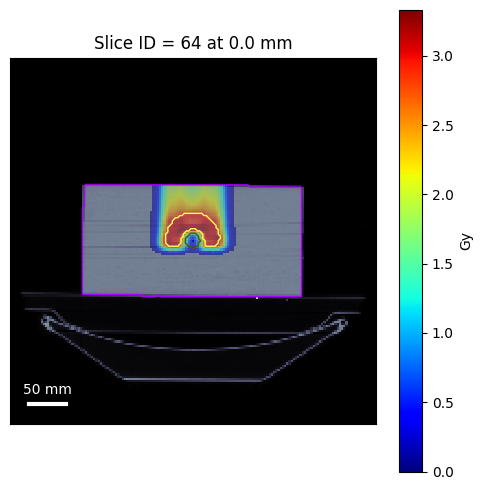

In [6]:
if GUI_AVAILABLE:
    # Use the GUI if [gui] dependencies are installed
    launch_viewer(ct, cst, result_mimicked)
else:
    # Choose a slice to visualize
    view_slice = int(np.round(ct.size[2] / 2))

    # Visualize
    plot_slice(
        image_volume=ct,
        cst=cst,
        overlay=result_mimicked["physical_dose"],
        view_slice=view_slice,
        plane="axial",
        overlay_unit="Gy",
    )